# **Finding Correlation**


We will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


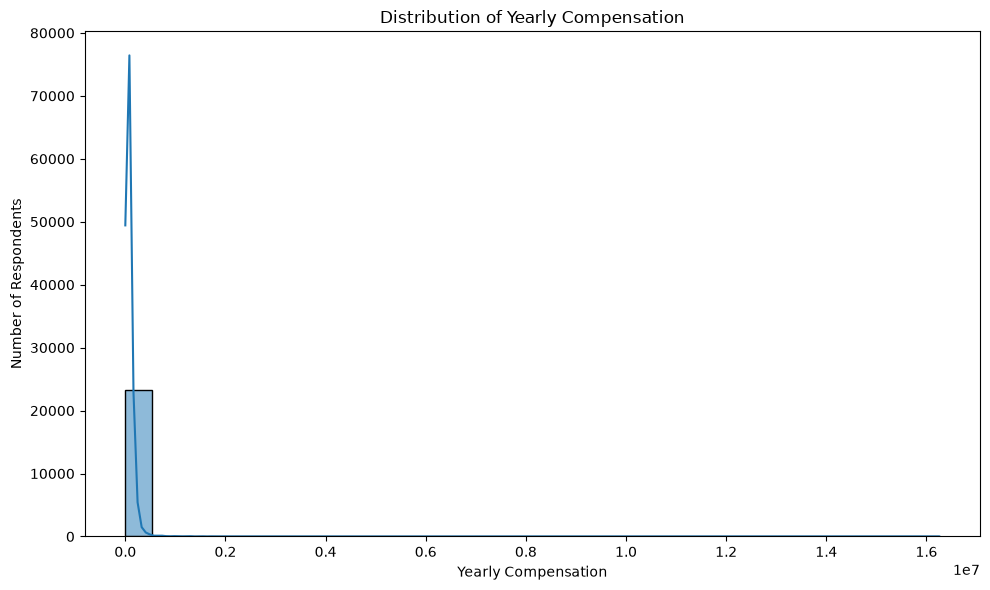

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    df['ConvertedCompYearly'].dropna(),
    bins=30,
    kde=True
)

plt.title('Distribution of Yearly Compensation')
plt.xlabel('Yearly Compensation')
plt.ylabel('Number of Respondents')

plt.tight_layout()
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [4]:
# Filter full-time employees
full_time = df[df['Employment'] == 'Employed, full-time']

# Calculate median compensation
median_compensation = full_time['ConvertedCompYearly'].median()

print("Median compensation for full-time employees:", median_compensation)

Median compensation for full-time employees: 69814.0

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



For Step 5, the goal is to compare ConvertedCompYearly across different countries using box plots.

Because your dataset has many countries, plotting every country will make the chart unreadable. A good approach is to use the top 10 countries by number of respondents.

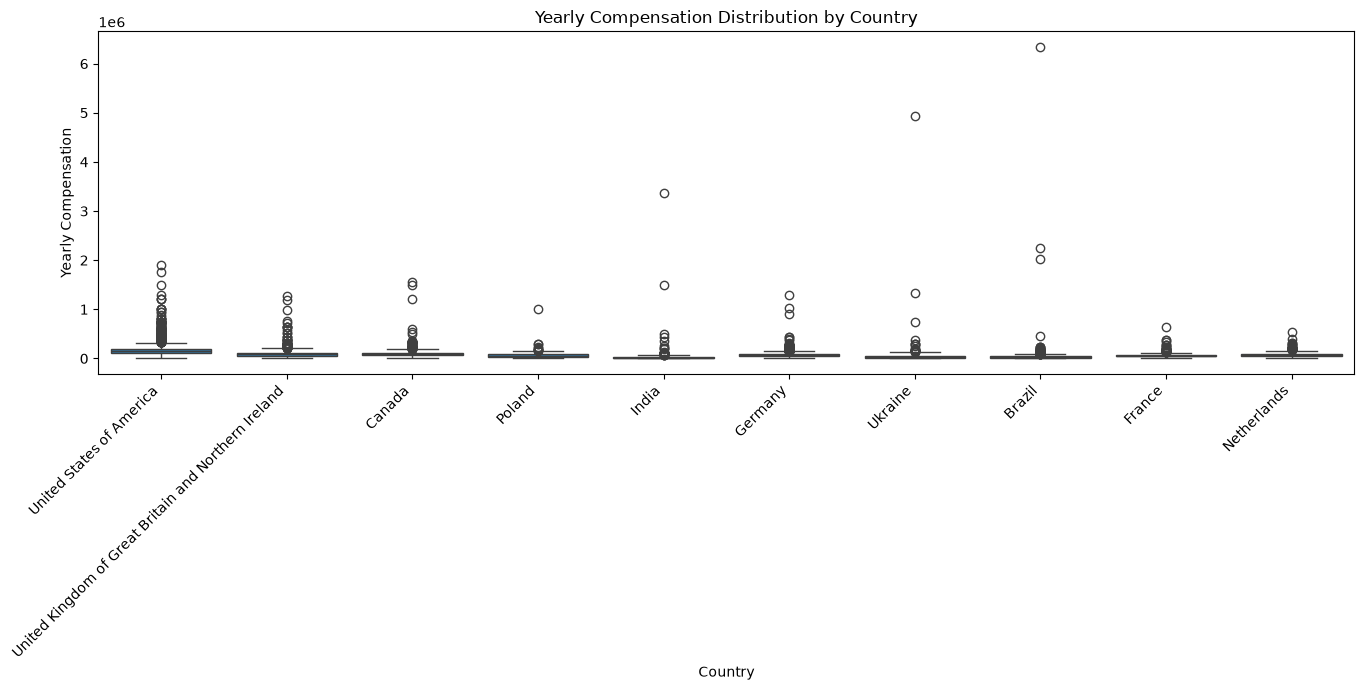

In [5]:
# Get the 10 countries with the most respondents
top_countries = df['Country'].value_counts().head(10).index

# Filter the data
df_top_countries = df[df['Country'].isin(top_countries)]

# Create box plot
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_top_countries,
    x='Country',
    y='ConvertedCompYearly'
)

plt.title('Yearly Compensation Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Yearly Compensation')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Because you have extreme compensation values

Your previous box plot showed very large outliers. Those can make the country comparison difficult to see.

For a clearer visualization, you can limit the y-axis:

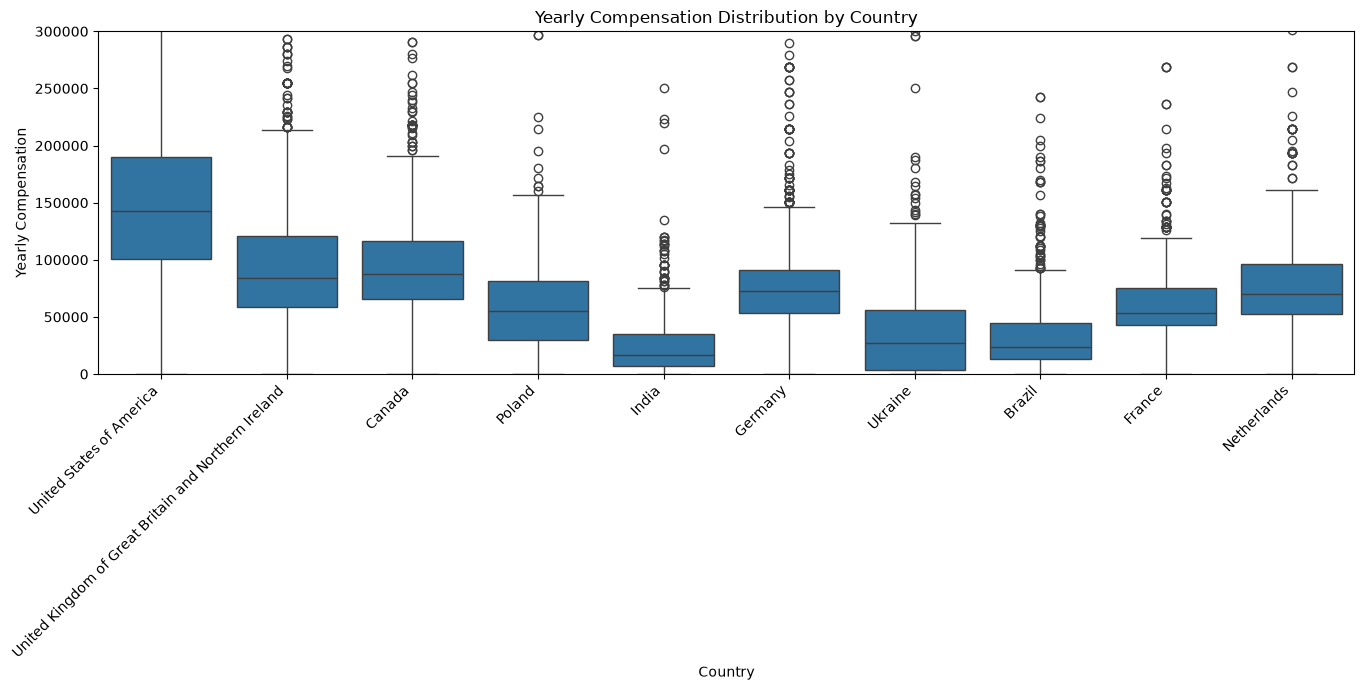

In [6]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_top_countries,
    x='Country',
    y='ConvertedCompYearly'
)

plt.ylim(0, 300000)

plt.title('Yearly Compensation Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Yearly Compensation')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [6]:
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Why .copy()?

It creates an independent DataFrame rather than just a view of df. This is useful because you'll be using df_no_outliers for the correlation analysis in the next steps.

You can also check how many rows were removed:

In [7]:
# Remove only the outliers from ConvertedCompYearly
df_no_outliers = df[
    df['ConvertedCompYearly'].isna() |
    df['ConvertedCompYearly'].between(lower_bound, upper_bound)
].copy()

print("Original dataset:", df.shape)
print("Dataset after removing outliers:", df_no_outliers.shape)
print("Rows removed:", len(df) - len(df_no_outliers))

Original dataset: (65437, 114)
Dataset after removing outliers: (64459, 114)
Rows removed: 978

<h3>Step 7: Finding Correlations Between Key Variables</h3>


Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [8]:
# Select the required columns
correlation_data = df_no_outliers[
    ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
]

# Calculate correlations
correlation_matrix = correlation_data.corr()

print(correlation_matrix)

                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.408438       -0.058170
WorkExp                         0.408438  1.000000       -0.028027
JobSatPoints_1                 -0.058170 -0.028027        1.000000

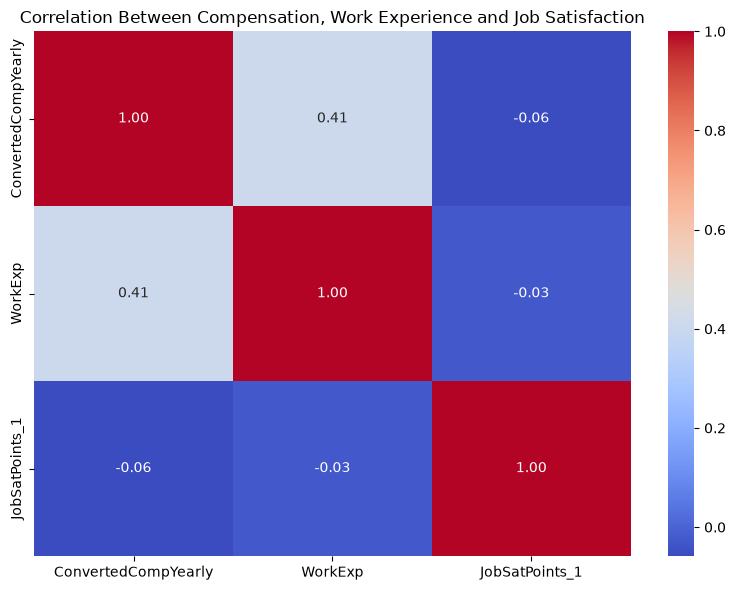

In [9]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Compensation, Work Experience and Job Satisfaction')
plt.tight_layout()
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


Plot 1 — Compensation vs WorkExp

Look for whether the points generally move upward as WorkExp increases.

Upward pattern → positive correlation
No clear pattern → weak/no correlation
Downward pattern → negative correlation

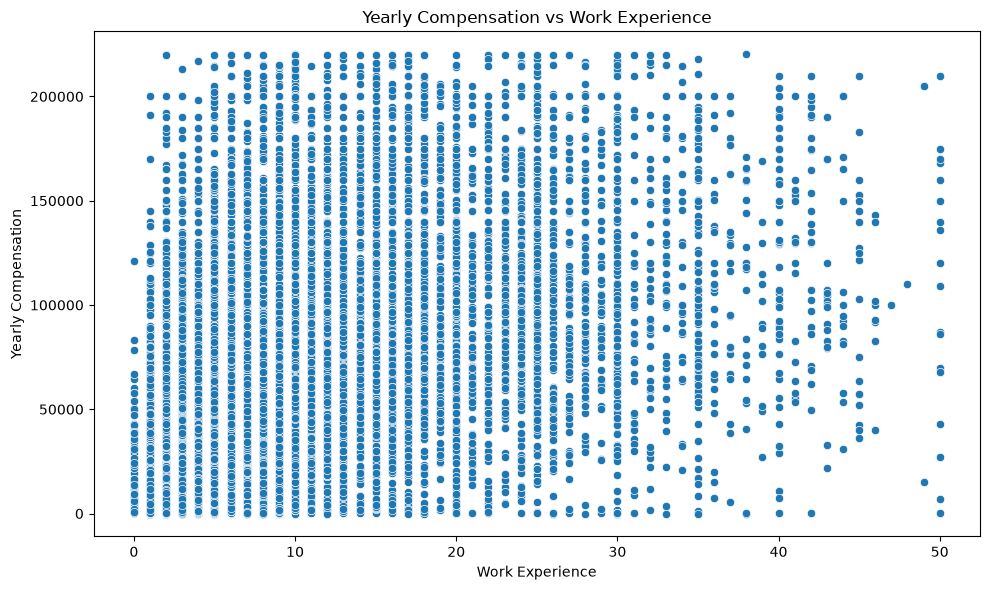

In [10]:
# Scatter plot: Compensation vs Work Experience
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_no_outliers,
    x='WorkExp',
    y='ConvertedCompYearly'
)

plt.title('Yearly Compensation vs Work Experience')
plt.xlabel('Work Experience')
plt.ylabel('Yearly Compensation')

plt.tight_layout()
plt.show()

Plot 2 — Compensation vs JobSatPoints_1

Look for whether higher job-satisfaction scores are associated with higher compensation.

⭐ Important

Use df_no_outliers, not df, because Step 6 specifically asked you to remove compensation outliers before continuing with the correlation analysis.

These scatter plots should visually support the correlation values you calculated in Step 7.

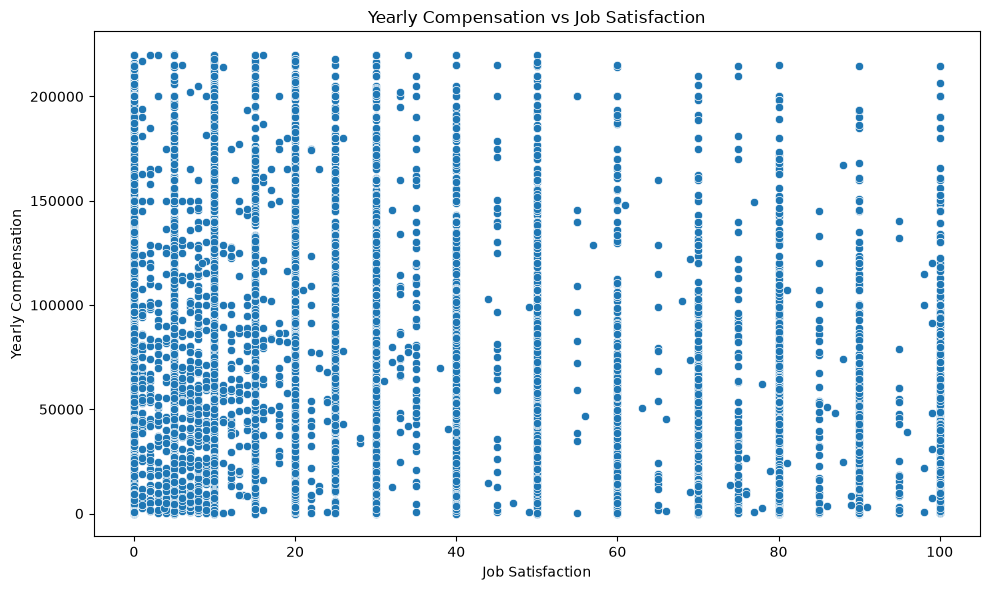

In [17]:
# Scatter plot: Compensation vs Job Satisfaction
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_no_outliers,
    x='JobSatPoints_1',
    y='ConvertedCompYearly'
)

plt.title('Yearly Compensation vs Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Yearly Compensation')

plt.tight_layout()
plt.show()

<h3>Summary</h3>


- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, I have developed a solid foundation for analyzing relationships within the dataset.
